In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from datetime import timedelta
from pandas.plotting import register_matplotlib_converters
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.arima.model import ARIMA
register_matplotlib_converters()
from time import time
import matplotlib.pyplot as plt
from warnings import filters
import jax.numpy as jnp
import jax
from caskade import Param, forward
import numpy as np
import pandas as pd
from tinygp import GaussianProcess, kernels
import jaxopt
from astropy.cosmology import Planck18
from lightcurvelynx.astro_utils.passbands import PassbandGroup
from lightcurvelynx.astro_utils.redshift import RedshiftDistFunc
from lightcurvelynx.base_models import FunctionNode
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc
from lightcurvelynx.math_nodes.ra_dec_sampler import ObsTableRADECSampler
from lightcurvelynx.math_nodes.scipy_random import SamplePDF
from lightcurvelynx.models.agn import AGN
from lightcurvelynx.obstable.opsim import OpSim
from lightcurvelynx.simulate import simulate_lightcurves
from lightcurvelynx.utils.plotting import plot_lightcurves
from lightcurvelynx.survey_info import SurveyInfo
import math 

In [13]:
# TODO: Look at interplay between GP params, wavelength and redshift. 
# copy-pasted from tiny_gp_experiments.ipynb:

passband_group = PassbandGroup.from_preset(
    preset="LSST",
)
# It will take a while to download it. It took 9 min on Helen
obstable = OpSim.from_url(
    "https://s3df.slac.stanford.edu/data/rubin/sim-data/sims_featureScheduler_runs4.3/baseline/baseline_v4.3.5_10yrs.db",
)

#chekc out https://lightcurvelynx.readthedocs.io/en/latest/notebooks/pre_executed/agn.html#AGN-Damped-Random-Walk-Example

lg_bh_mass = NumpyRandomFunc("uniform", low=7.0, high=9.0)

#I'll just keep this instead of caskade because I'm only gathering some preliminaruy data, will not have it written in final code
bh_mass = FunctionNode(
    lambda lg_mass: 10**lg_mass,
    lg_mass=lg_bh_mass,
    node_label="bh_mass",
)


def edd_ratio_pdf(value):
    xi = 10**-1.65
    lambda_br = 10**-1.84
    delta1 = 0.471 - 0.7
    delta2 = 2.53
    min_lambda = 0.01
    max_lambda = 1.0
    value = np.asarray(value)
    fill_mask = (value >= min_lambda) & (value <= max_lambda)
    prob = np.zeros_like(value)
    prob[fill_mask] = xi / (
        (value[fill_mask] / lambda_br) ** delta1 + (value[fill_mask] / lambda_br) ** delta2
    )
    return prob

edd_ratio = SamplePDF(edd_ratio_pdf)

radec = ObsTableRADECSampler(
    obstable,
    radius=3.0,  # degrees
    node_label="ra_dec_sampler",
)

bh_mass = 1e8
edd_ratio = 0.25

model = AGN(
    t0=obstable.time_bounds()[0],
    redshift=0.1,
    cosmology=Planck18,
    passband_group=passband_group,
    redshift_dist_func=0,
    blackhole_mass=bh_mass,
    ra=radec.ra,
    dec=radec.dec,
    edd_ratio=edd_ratio,
)

survey_info = SurveyInfo(obstable=obstable, passband_group=passband_group)

rng = np.random.default_rng(501)

n = 1

df = simulate_lightcurves(
    model=model,
    num_samples=n,
    survey_info=survey_info,
    # param_cols=[
    #     "bh_mass.lg_mass",
    #     "AGN_0.edd_ratio"
    # ],       
    rng=rng)

Simulating: 100%|██████████| 1/1 [00:00<00:00,  6.22obj/s]


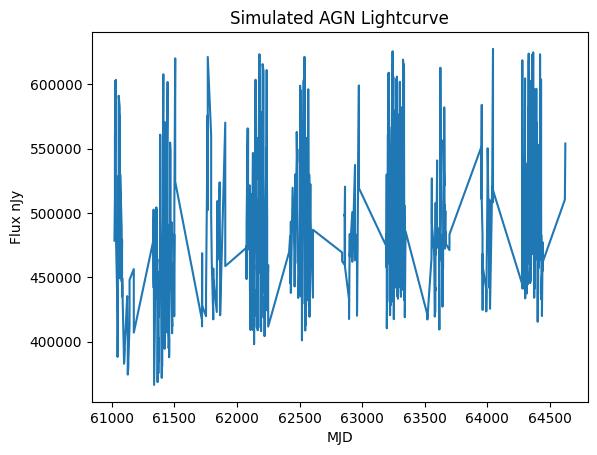

In [14]:
lightcurve = df.loc[0, "lightcurve"]
if lightcurve is None or "flux_perfect" not in lightcurve.columns:
    print(f"Warning: Sample {i} has no lightcurve data or missing 'flux_perfect' column. Skipping.")
sample_data = pd.DataFrame(lightcurve)[["mjd", "flux_perfect"]]
x = sample_data.loc[:, "mjd"]
y = sample_data.loc[:, "flux_perfect"]

plt.plot(x, y)
plt.xlabel("MJD")
plt.ylabel("Flux nJy")
plt.title("Simulated AGN Lightcurve")
plt.show()
    

[ 1.00000000e+00 -2.41345280e-02  8.23381217e-02 -2.42638539e-02
  1.23698997e-02  3.54771754e-03  6.79074290e-03  5.67609155e-05
  7.43436494e-03 -1.43462139e-02  6.72123674e-03  1.36175876e-02
  1.57661275e-02 -1.28412579e-02  3.05630436e-02 -1.16399078e-02
 -4.08054163e-03 -1.48630255e-02  3.34994222e-03  4.07595955e-03
  6.26619122e-04  9.98739821e-02  6.41037127e-04 -3.06653418e-03
  7.89391863e-03 -2.07763404e-02  1.30901354e-01 -1.80231085e-03
 -1.39777997e-03  6.82565568e-02]


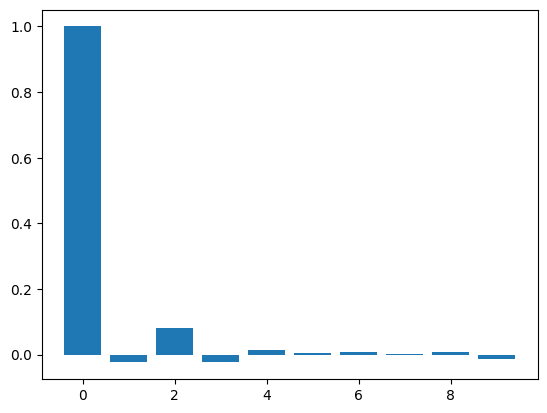

In [15]:
first_diff = x.diff()
first_diff = first_diff[1:]
acf_vals = acf(first_diff)
print(acf_vals)
num_lags = 10
plt.bar(range(num_lags), acf_vals[:num_lags])
plt.show()

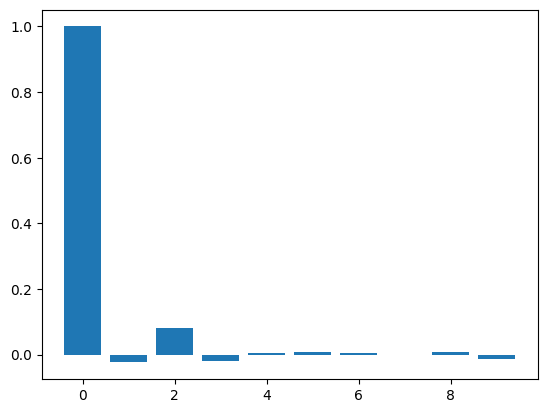

In [16]:
pacf_vals = pacf(first_diff)
plt.bar(range(num_lags), pacf_vals[:num_lags])
plt.show()

Based on these plots, w'll make an ARMA(1,1) plot, at least to begin with. In the reference code I found the ARMA model is trained on the first difference, so I will do the same. Note that this assumes uniform cadence, which is not a valid assumption in our case, but I will generalize it later. 

In [23]:
model = ARIMA(first_diff, order=(1, 1, 0), seasonal_order=(0, 0, 0, 0))
start = time()
model_fit = model.fit()
end = time()
print('Model Fitting Time:', end - start)
model_fit.summary()

Model Fitting Time: 0.06174111366271973


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                    mjd   No. Observations:                  815
Model:                 ARIMA(1, 1, 0)   Log Likelihood               -3820.202
Date:                Mon, 01 Jun 2026   AIC                           7644.403
Time:                        08:54:05   BIC                           7653.807
Sample:                             0   HQIC                          7648.013
                                - 815                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5719      0.008    -75.057      0.000      -0.587      -0.557
sigma2       697.7553      7.454     93.603      0.000     683.145     712.366
===================================================================================
Ljung-Box (L1) (Q):                  21.01   Jarque-Bera (JB):             58942.16
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.72   Skew:                             3.64
Prob(H) (two-sided):                  0.00   Kurtosis:                        44.05
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

So our model is:
y_t = -0.57y_(t-1) + 0.52eps_t

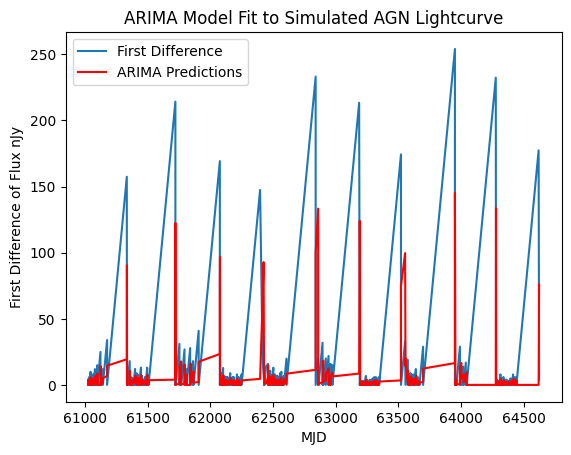

In [25]:
predictions = model_fit.predict(start=0, end=len(first_diff)-1)
plt.plot(x[1:], first_diff, label='First Difference')
plt.plot(x[1:], predictions, label='ARIMA Predictions', color='red')
plt.xlabel("MJD")
plt.ylabel("First Difference of Flux nJy")
plt.title("ARIMA Model Fit to Simulated AGN Lightcurve")
plt.legend()
plt.show()

To avoid last time's mistakes, I will check two things:
1 - I can initialize a full model with those simply learned parameters
2- Once I have a full mdoel, I can easily get its prediction at a certain time

In [ ]:
from statsmodels.tsa.arima.model import ARIMAResults
results = ARIMAResults()